In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

sns.set_theme(style="whitegrid")

# Full simulation walltimes (per run)
df4  = pd.read_csv('../output/gpu_topo_4_ranks_v3.csv')
df16 = pd.read_csv('../output/gpu_topo_16_ranks_v3.csv')

# Halo exchange timing (per iteration)
h4  = pd.read_csv('../output/halo_exchange_4_ranks.csv')
h16 = pd.read_csv('../output/halo_exchange_16_ranks.csv')

# Kernel timing (per iteration)
k4  = pd.read_csv('../output/kernel_timing_4_ranks.csv')
k16 = pd.read_csv('../output/kernel_timing_16_ranks.csv')

# y-lim so all whiskers are visible, no outlier space ---
def get_whisker_range(data, col):
    groups = data.groupby('topology')[col]
    lo_vals, hi_vals = [], []
    for _, vals in groups:
        q1, q3 = vals.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo_vals.append(max(vals.min(), q1 - 1.5 * iqr))
        hi_vals.append(min(vals.max(), q3 + 1.5 * iqr))
    return (min(lo_vals), max(hi_vals))

# padding for ylim
def ylim_with_pad(data, col, pad_frac=0.20):
    ymin, ymax = get_whisker_range(data, col)
    pad = (ymax - ymin) * pad_frac
    return (ymin - pad, ymax + pad)

# boxplot with consistent style
def boxplot(df, x, y, ax, title, ylabel, ylim=None):
    sns.boxplot(data=df, x=x, y=y,
                palette='viridis', hue=x, legend=False,
                linewidth=2, showfliers=False, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Topology', fontsize=12, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=12, labelpad=8)
    if ylim is not None:
        ax.set_ylim(ylim)
    return ax



# Basic Benchmarks

Total simulation walltime per run (from `gpu_topo_*_ranks_v3.csv`).
Each run executes nt=100 timesteps on the full global grid.

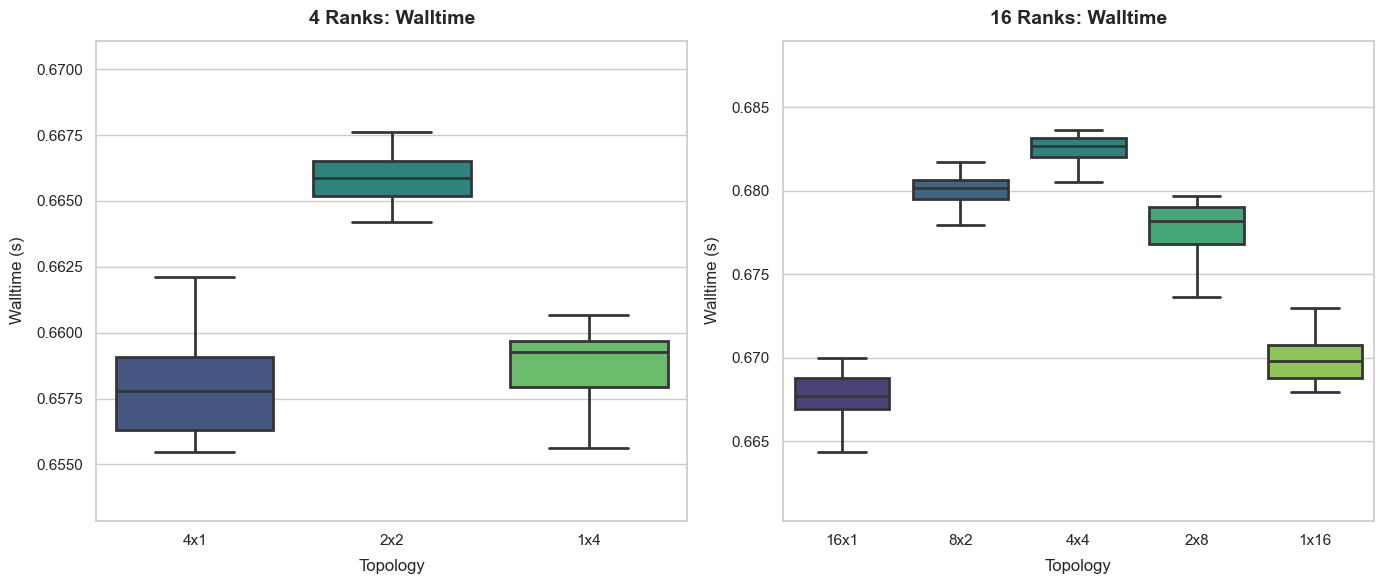

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

boxplot(df4, 'topology', 'walltime', axes[0],
        '4 Ranks: Walltime', 'Walltime (s)',
        ylim=ylim_with_pad(df4, 'walltime'))

boxplot(df16, 'topology', 'walltime', axes[1],
        '16 Ranks: Walltime', 'Walltime (s)',
        ylim=ylim_with_pad(df16, 'walltime'))

plt.tight_layout()
plt.show()


The x-axis shows the MPI rank decomposition (e.g. 4x1, 2x2, 1x4).
Lower walltime is better.

---
# Advanced Benchmark Metrics

Per-iteration profiling of compute kernels and MPI halo exchange.

In [53]:
# --- Compute derived metrics ---

# 1. Kernel MLUPS: one value per kernel iteration
for df in [k4, k16]:
    df['kernel_mlups'] = df['nx_local'] * df['ny_local'] / df['kernel_walltime_seconds'] / 1e6

# 2. Communication Share: cross-product of kernel x halo iterations per topology
def compute_comm_share(halo_df, kernel_df):
    rows = []
    for topo in halo_df['topology'].unique():
        h_sub = halo_df[halo_df['topology'] == topo]
        k_sub = kernel_df[kernel_df['topology'] == topo]
        meta = h_sub.iloc[0][['nprocs','topology','nx_global','ny_global','nx_local','ny_local']].to_dict()
        for (_, hrow), (_, krow) in product(h_sub.iterrows(), k_sub.iterrows()):
            share = hrow['halo_walltime_seconds'] / (hrow['halo_walltime_seconds'] + krow['kernel_walltime_seconds']) * 100
            r = meta.copy()
            r['comm_share_pct'] = share
            rows.append(r)
    return pd.DataFrame(rows)

c4  = compute_comm_share(h4, k4)
c16 = compute_comm_share(h16, k16)

# 3. Total Effective MLUPS
for df in [df4, df16]:
    interior = (df['nx_global'] - 2) * (df['ny_global'] - 2)
    df['total_mlups'] = interior * df['nt'] / df['walltime'] / 1e6
# 4. Communication Cost per Local Cell (ns)
for df in [h4, h16]:
    df['comm_cost_ns'] = df['halo_walltime_seconds'] / (df['nx_local'] * df['ny_local']) * 1e9


## Kernel MLUPS & Communication Share

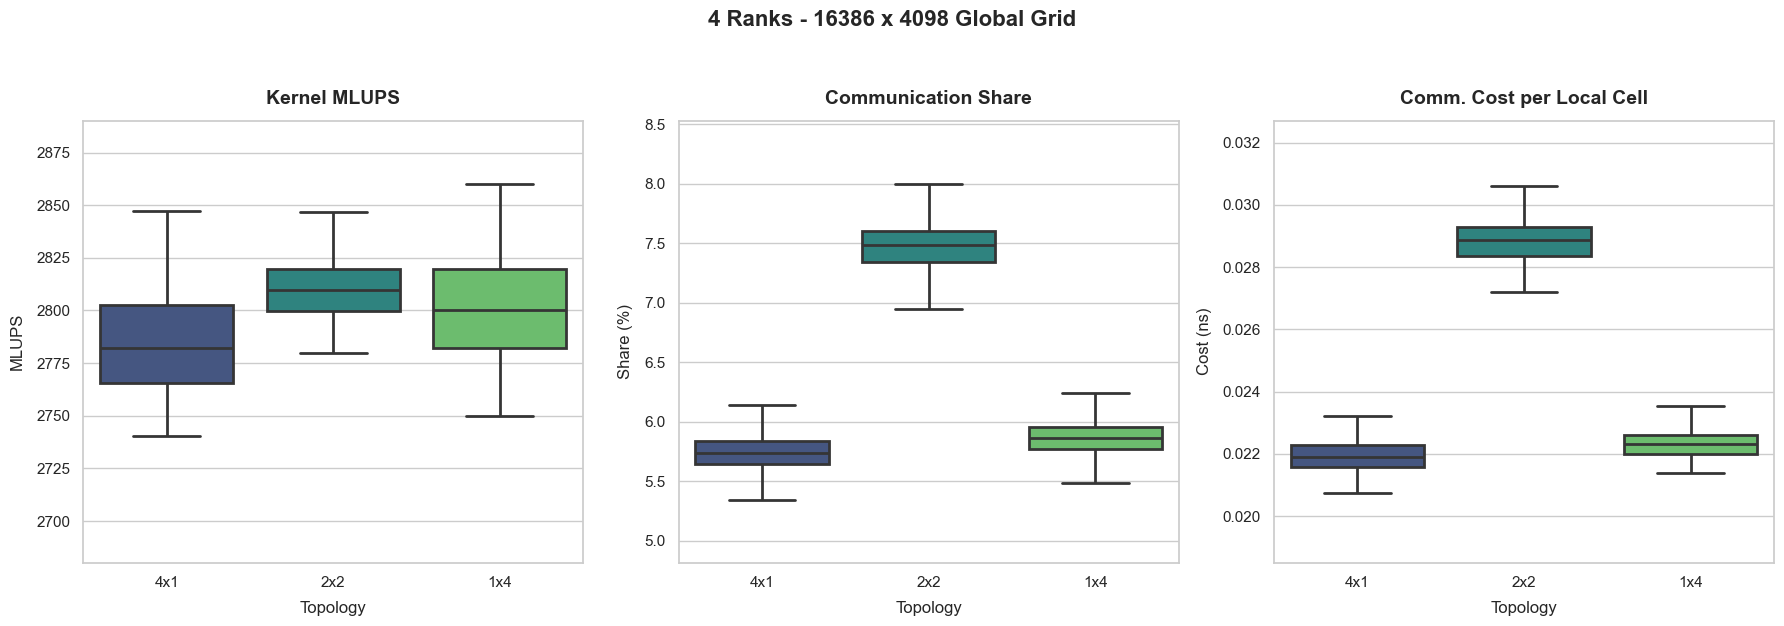

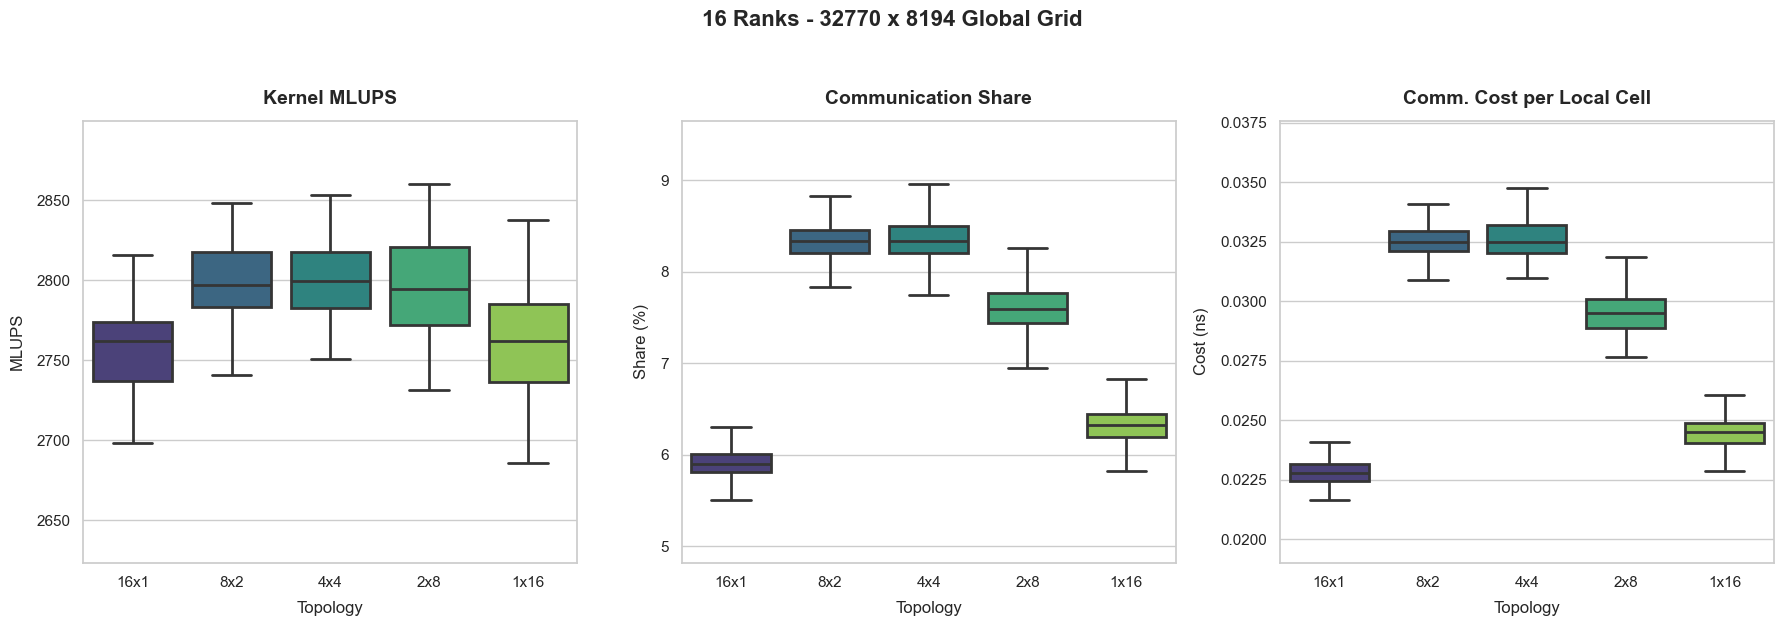

In [ ]:
def plot_3panel(kdf, cdf, hdf, suptitle):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    boxplot(kdf, 'topology', 'kernel_mlups', axes[0],
            'Kernel MLUPS', 'MLUPS',
            ylim=ylim_with_pad(kdf, 'kernel_mlups'))
    boxplot(hdf, 'topology', 'comm_cost_ns', axes[2],
                        'Communication Cost per Local Cell', 'Cost (ns)',
                        ylim=ylim_with_pad(hdf, 'comm_cost_ns'))
    boxplot(cdf, 'topology', 'comm_share_pct', axes[1],
            'Communication Share', 'Share (%)',
            ylim=ylim_with_pad(cdf, 'comm_share_pct'))
    
    fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.show()

plot_3panel(k4, c4, h4, '4 Ranks - 16386 x 4098 Global Grid')
plot_3panel(k16, c16, h16, '16 Ranks - 32770 x 8194 Global Grid')

## Total Effective MLUPS (System Level)

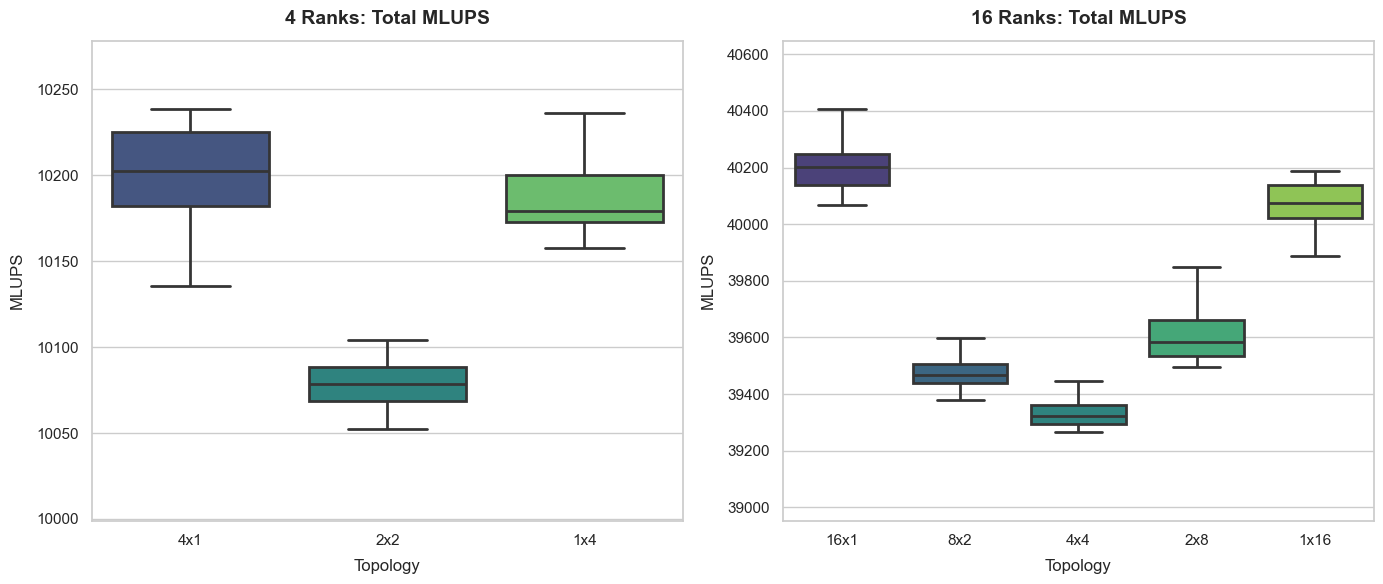

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

boxplot(df4, 'topology', 'total_mlups', axes[0],
        '4 Ranks: Total MLUPS', 'MLUPS',
        ylim=ylim_with_pad(df4, 'total_mlups'))

boxplot(df16, 'topology', 'total_mlups', axes[1],
        '16 Ranks: Total MLUPS', 'MLUPS',
        ylim=ylim_with_pad(df16, 'total_mlups'))

plt.tight_layout()
plt.show()


---

### Metric Definitions

| Metric | Formula | Data Source | Description |
|---|---|---|---|
| **Walltime** | measured total run time (s) | gpu_topo (per run) | End-to-end simulation time for nt=100 steps |
| **Kernel MLUPS** | $\frac{\text{nx\_local} \times \text{ny\_local}}{\text{kernel\_runtime\_seconds}} \times 10^{-6}$ | kernel_timing (per iteration) | Pure compute throughput per rank |
| **Communication Share** | $\frac{t_{\text{halo}}}{t_{\text{kernel}} + t_{\text{halo}}} \times 100\%$ | cross-product of halo x kernel iterations | Fraction of iteration time spent on MPI halo exchange |
| **Total MLUPS** | $\frac{(\text{nx\_global} - 2) \times (\text{ny\_global} - 2) \times \text{nt}}{\text{walltime}} \times 10^{-6}$ | gpu_topo (per run) | Overall simulation throughput on the full cluster |
| **Comm. Cost per Cell** | $\frac{t_{\text{halo}}}{\text{nx\_local} \times \text{ny\_local}} \times 10^{9}$ | halo_exchange (per iteration) | MPI overhead normalised by local grid size (ns per cell) |
